In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    kruskal,
    mannwhitneyu,
    spearmanr,
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

meta_path = (
    r"C:\Users\cmkua\Downloads"
    r"\LIBS_acoustic_meta_sheet_v4_293.csv"
)

df = pd.read_csv(meta_path)

print(df.shape)
print(df["Region"].value_counts())
print(df.columns.tolist())

(293, 26)
Region
Crater Floor    185
Upper Fan        55
Delta            53
Name: count, dtype: int64
['File Name', 'Formation', 'Member', 'Onset (s)', 'Slope (dB/s)', 'R^2', 'Drop Time (s)', 'C2 (dB)', 'Spectral Centroid (Hz)', 'Spectral Bandwidth (Hz)', 'Peak Frequency (Hz)', 'Rolloff 85% (Hz)', 'Low Power 1-10 kHz', 'High Power 10-30 kHz', 'High/Low Ratio', 'High Frequency Fraction', 'Total FFT Power', 'Recovery Method', 'Flagged', 'Sample Rate (Hz)', 'Peak Time (s)', 'Peak-Onset Lag (ms)', 'Pass2 Expected Time (s)', 'Region', 'Dataset Source', 'Processing Version']


In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.3 MB 26.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 25.0 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\cmkua\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np

# Create a positive decay rate column
df["Decay Rate (dB/s)"] = -df["Slope (dB/s)"]

metrics = [
    "Decay Rate (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Spectral Bandwidth (Hz)",
    "Peak Frequency (Hz)",
    "Rolloff 85% (Hz)",
    "High/Low Ratio",
    "High Frequency Fraction",
]

summary = (
    df.groupby("Region")[metrics]
      .agg(["count","mean","median","std","min","max"])
      .round(2)
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
summary

Decay Rate (dB/s)                                                \
                         count     mean   median      std      min       max   
Region                                                                         
Crater Floor               185  3881.11  3019.39  3370.03   251.37  21678.29   
Delta                       53  8363.33  7030.84  6111.03  2463.46  36552.87   
Upper Fan                   55  8715.67  6126.00  9337.22   897.80  44019.12   

             C2 (dB)                                   Spectral Centroid (Hz)  \
               count   mean median   std    min    max                  count   
Region                                                                          
Crater Floor     185  10.80  12.28  6.08 -10.12  21.05                    185   
Delta             53  15.41  16.93  6.15 -14.43  22.51                     53   
Upper Fan         55  15.26  16.03  6.16 -23.32  23.20                     55   

                                                            \
                 mean   median      std      min       max   
Region                                                       
Crater Floor  8496.64  7760.28  3196.47  3789.53  25050.48   
Delta         6890.86  6608.12   957.67  5443.95  11646.41   
Upper Fan     7298.69  6867.60  1811.64  5635.79  15804.21   

             Spectral Bandwidth (Hz)                                      \
                               count     mean   median      std      min   
Region                                                                     
Crater Floor                     185  8092.95  7572.24  3212.98  2189.35   
Delta                             53  3321.75  3125.87   796.51  2206.60   
Upper Fan                         55  3681.52  3341.53  1198.59  2051.05   

                       Peak Frequency (Hz)                                    \
                   max               count     mean  median      std     min   
Region                                                                         
Crater Floor  16509.14                 185  5366.49  4700.0  4871.43  1000.0   
Delta          6737.20                  53  5473.58  5300.0  1549.21  2700.0   
Upper Fan      7078.66                  55  7185.45  5500.0  4933.76  3100.0   

                      Rolloff 85% (Hz)                                     \
                  max            count      mean  median      std     min   
Region                                                                      
Crater Floor  39100.0              185  13449.19  9700.0  8561.15  5900.0   
Delta          9100.0               53   9664.15  9100.0  2058.57  7600.0   
Upper Fan     19500.0               55  10618.18  9500.0  3585.83  7500.0   

                      High/Low Ratio                                 \
                  max          count  mean median   std   min   max   
Region                                                                
Crater Floor  45600.0            185  0.15   0.11  0.17  0.02  1.92   
Delta         20700.0             53  0.17   0.13  0.17  0.05  1.09   
Upper Fan     19600.0             55  0.24   0.14  0.44  0.04  3.04   

             High Frequency Fraction                                 
                               count  mean median   std   min   max  
Region                                                               
Crater Floor                     185  0.07   0.06  0.05  0.00  0.36  
Delta                             53  0.13   0.11  0.08  0.05  0.52  
Upper Fan                         55  0.16   0.13  0.13  0.03  0.75

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


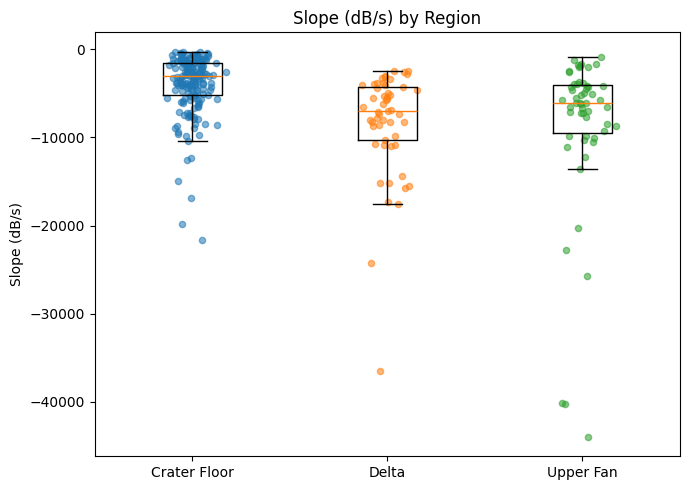

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


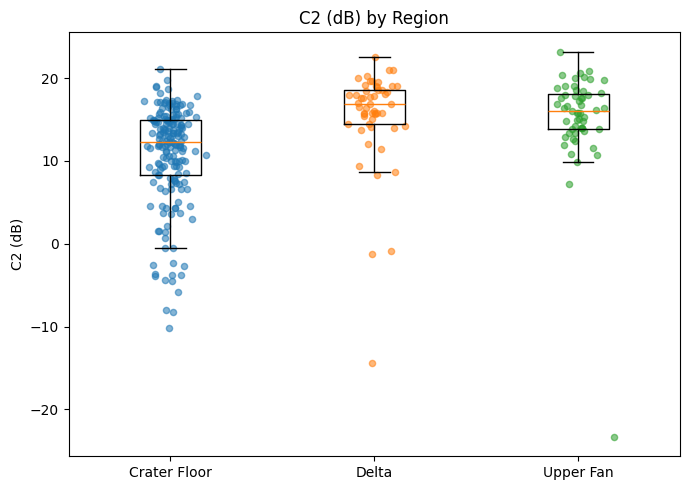

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


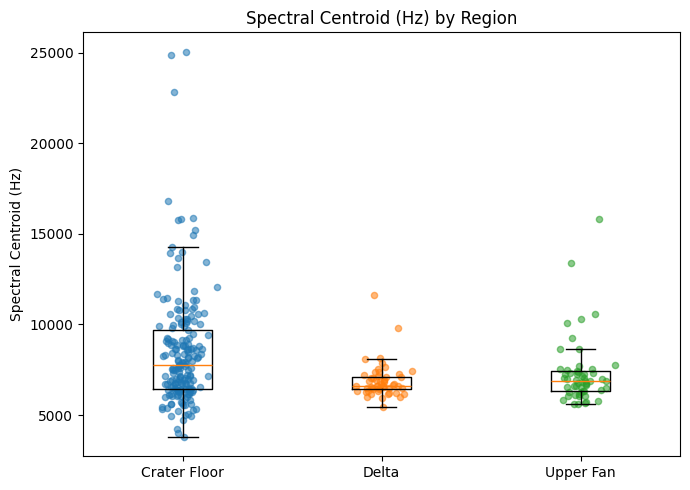

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


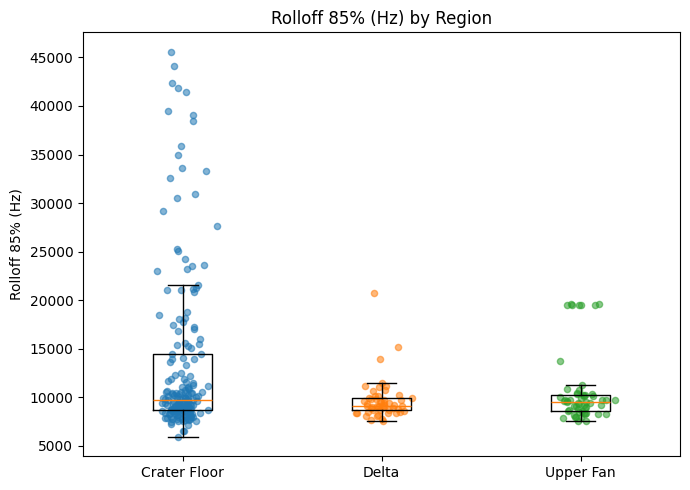

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


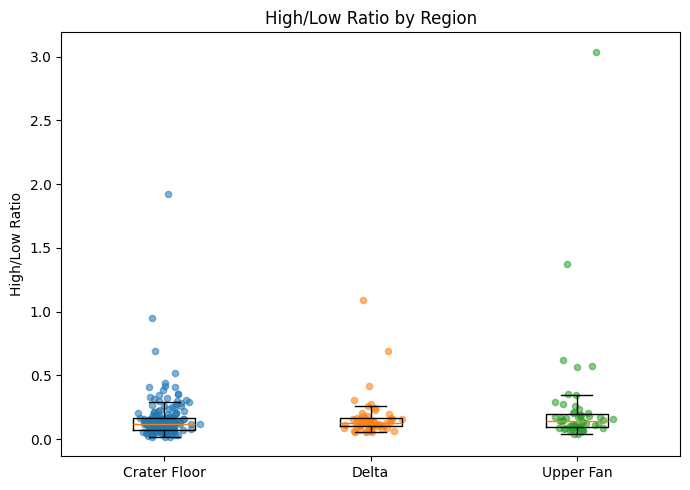

C:\Users\cmkua\AppData\Local\Temp\ipykernel_34692\2122396150.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


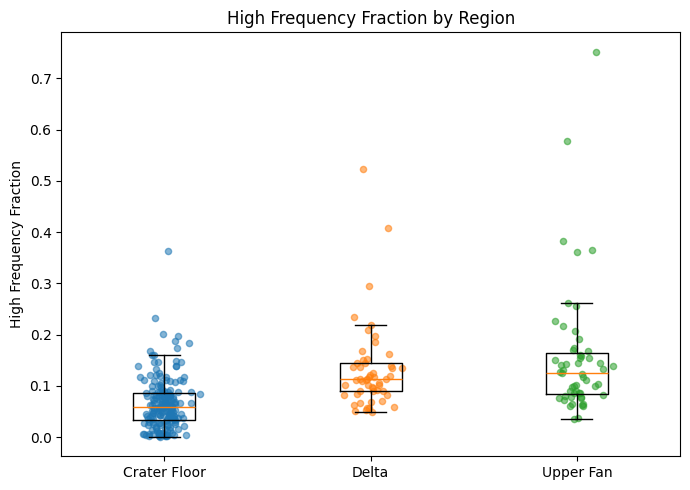

In [10]:
metrics = [
    "Slope (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Rolloff 85% (Hz)",
    "High/Low Ratio",
    "High Frequency Fraction",
]

region_order = [
    "Crater Floor",
    "Delta",
    "Upper Fan",
]

for metric in metrics:

    plot_df = df[
        ["Region", metric]
    ].dropna()

    grouped = [
        plot_df.loc[
            plot_df["Region"] == region,
            metric
        ].values
        for region in region_order
    ]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        grouped,
        labels=region_order,
        showfliers=False,
    )

    rng = np.random.default_rng(42)

    for i, region in enumerate(
        region_order,
        start=1
    ):
        values = plot_df.loc[
            plot_df["Region"] == region,
            metric
        ].values

        jitter = rng.normal(
            loc=i,
            scale=0.06,
            size=len(values),
        )

        plt.scatter(
            jitter,
            values,
            alpha=0.55,
            s=20,
        )

    plt.ylabel(metric)
    plt.title(f"{metric} by Region")
    plt.tight_layout()
    plt.show()